# Palace 2D Mode Analysis: Travelling-Wave Mach-Zehnder Modulator

This notebook builds a simplified cross-section of a Travelling-Wave Mach-Zehnder Modulator (TW-MZM) with a PN-junction embedded in a rib waveguide, using CPW electrodes for RF modulation.

**Cross-section geometry (from literature):**
- **SOI substrate**: 220 nm Si on 2 um buried oxide (BOX)
- **Rib waveguide**: 400 nm width, 90 nm slab height
- **CPW electrodes**: Aluminium, 1 um thick, signal width $w=20$ um, gap $g=20$ um
- **PN junction**: Centred in the rib with P+/N+ contact regions in the slab

We use `BoundaryModeSim` (Palace 2D eigenmode solver) to compute both RF and optical modes.

**Requirements:**
- gdsfactory + generic PDK (`gf.gpdk`)
- A Palace binary resolved internally by `run_local()` (e.g. `palace-toolkit-cpu`, `PALACE_BIN`, or `palace` on PATH)
- [GDSFactory+](https://gdsfactory.com) account only for cloud runs

**Workflow:** parameters are grouped next to the stage they configure — geometry &amp; materials, then RF, then optical.


## Geometry &amp; materials parameters

Define the layout dimensions, the substrate/metal stack, and the doping
(geometry + material) for the rib and graded slab regions. These are consumed
by the geometry build and by
`gsim.common.cross_section.build_doped_cross_section()`.

The generic helpers used here are PDK-agnostic — no hardcoded values live in
the notebook.

**Layer assignments (gpdk):**
- `WG` (1,0): Waveguide core (220 nm Si, 400 nm wide)
- `SLAB90` (3,0): 90 nm slab regions
- `N` (20,0) / `P` (21,0): PN junction doping
- `NPP` (24,0) / `PP` (23,0): N+/P+ graded contact doping (via `make_doping_profile`)
- `M1` (41,0): CPW electrodes (Al, 1 um thick)


In [1]:
# =============================================================================
#  Geometry & materials parameters
# =============================================================================

# --- Device / rib geometry (um) ---------------------------------------------
RIB_WIDTH = 0.4  # rib waveguide width
RIB_HEIGHT = 0.22  # rib waveguide height (z)
SLAB_THICKNESS = 0.09  # slab height (z) on each side of the rib
SLAB_HALF = 50.0  # slab half-width (y, on each side of the rib)
SIG_WIDTH = 20.0  # CPW signal electrode width
GAP_WIDTH = 20.0  # CPW signal-to-ground gap
GND_WIDTH = 40.0  # CPW ground electrode width
LENGTH = 10.0  # layout length along the propagation axis (x)
TOTAL_HALF = SIG_WIDTH / 2 + GAP_WIDTH + GND_WIDTH  # lateral half-extent
RIB_CENTER_Y = -(SIG_WIDTH / 2 + GAP_WIDTH / 2)  # rib centre y (=-20)

VIA_SIZE = 2.7  # via_stack footprint (square)
VIA_S_TO_P_Y = -9.0  # via from signal to P+ contact (y)
VIA_G_TO_N_Y = -29.0  # via from ground to N+ contact (y)

# --- Substrate stack (um) -----------------------------------------------------
BOX_THICKNESS = 2.0  # buried-oxide thickness (below z=0)
METAL1_ZMIN = 1.1  # metal1 bottom (top of the oxide stack)
METAL1_THICKNESS = 1.0  # CPW electrode thickness on metal1

# --- PN junction / doping material model -------------------------------------
SI_PERMITTIVITY = 11.9
FMAX_RF_MATERIAL = 200e9  # validity range of the constant-eps doping models (Hz)
RIB_DOPING_SIGMA = 1.6e3  # p_rib / n_rib junction conductivity (S/m)

# Graded slab doping {side: [(width_um, sigma_S_per_m), ...]}, from the rib edge.
DOPING_PROFILE = {
    "upper": [(2.0, 2.0e4), (2.0, 8.0e4)],  # P+ graded (toward signal)
    "lower": [(2.0, 2.0e4), (2.0, 8.0e4)],  # N+ graded (toward ground)
}
DOPING_SIDES = {  # config passed to make_doping_profile()
    "upper": {"base_layer": (23, 0), "name_prefix": "pp_slab_", "sign": 1},
    "lower": {"base_layer": (24, 0), "name_prefix": "npp_slab_", "sign": -1},
}

# --- Cross-section plane ------------------------------------------------------
CROSS_SECTION_AXIS = "x"
CROSS_SECTION_VALUE = 0.0

## Build TW-MZM cross-section geometry

The 3D layout component is sliced at $x=0$ for 2D mode analysis. The graded
doping regions are created with `make_doping_profile()` (no hardcoded geometry).


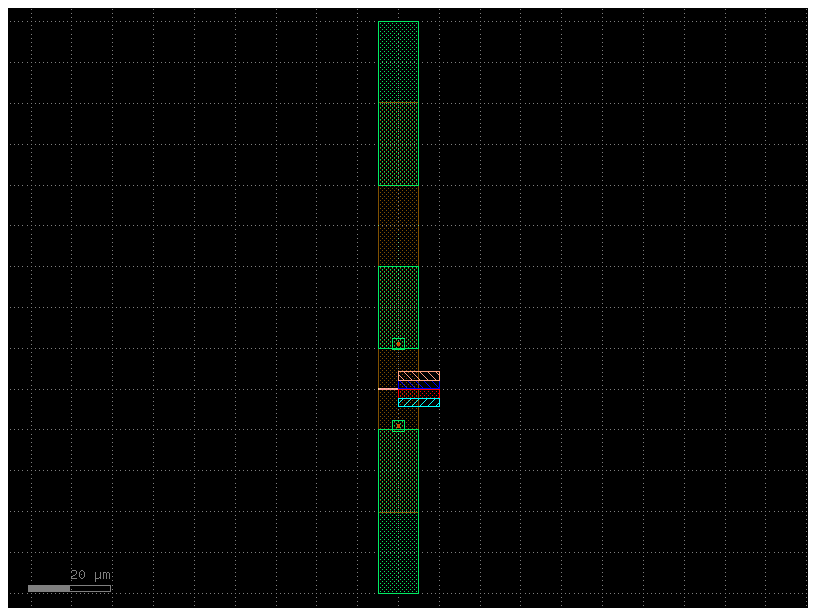

In [2]:
import gdsfactory as gf

from gsim.common.cross_section import build_optical_cross_section
from gsim.common.stack.doping import make_doping_profile

gf.gpdk.PDK.activate()

LAYER = gf.gpdk.LAYER


def centered_rect(wx: float, wy: float, layer) -> gf.Component:
    r = gf.Component()
    r << gf.c.rectangle((wx, wy), centered=True, layer=layer)
    return r


def _add_device_core(comp: gf.Component) -> None:
    """Rib + slab + PN junction — shared by the RF and optical components.

    The P/N rectangles are the same "doping profile" polygons in both, so the
    optical cross-section still shows the junction shape. The optical stack
    maps all four regions to plain silicon.
    """
    # 1. Rib waveguide core (PN junction sits inside it)
    wg = comp << centered_rect(LENGTH, RIB_WIDTH, LAYER.WG)
    wg.y = RIB_CENTER_Y

    # 2. Slab (90 nm)
    slab = comp << centered_rect(LENGTH, 2 * SLAB_HALF + RIB_WIDTH, LAYER.SLAB90)
    slab.y = 0.0

    # 3. PN junction (P above / N below the rib centre)
    p_half = comp << gf.c.rectangle((LENGTH, RIB_WIDTH / 2), layer=LAYER.P)
    p_half.y = RIB_CENTER_Y + RIB_WIDTH / 4
    n_half = comp << gf.c.rectangle((LENGTH, RIB_WIDTH / 2), layer=LAYER.N)
    n_half.y = RIB_CENTER_Y - RIB_WIDTH / 4


def _build_rf_component() -> tuple[gf.Component, dict]:
    """Full TW-MZM cross-section: device core + graded doping + CPW + vias."""
    comp = gf.Component()
    _add_device_core(comp)

    # 4. Graded N+/P+ slab doping (contiguous, no gaps)
    doping_result = make_doping_profile(
        comp,
        length=LENGTH,
        rib_center_y=RIB_CENTER_Y,
        rib_width=RIB_WIDTH,
        profile=DOPING_PROFILE,
        sides=DOPING_SIDES,
        zmin=0.0,
        zmax=SLAB_THICKNESS,
        permittivity=SI_PERMITTIVITY,
        fmax=FMAX_RF_MATERIAL,
    )

    # 5. CPW electrodes (M1)
    comp << centered_rect(LENGTH, SIG_WIDTH, LAYER.M1)
    gnd_top = comp << centered_rect(LENGTH, GND_WIDTH, LAYER.M1)
    gnd_top.y = SIG_WIDTH / 2 + GAP_WIDTH + GND_WIDTH / 2
    gnd_bot = comp << centered_rect(LENGTH, GND_WIDTH, LAYER.M1)
    gnd_bot.y = -(SIG_WIDTH / 2 + GAP_WIDTH + GND_WIDTH / 2)

    # 6. Vias at x=0 (signal-to-P+, ground-to-N+)
    via_s_to_p = comp << gf.c.via_stack(
        layers=("SLAB90", "M1"), vias=("viac", None), size=(VIA_SIZE, VIA_SIZE)
    )
    via_s_to_p.x = 0.0
    via_s_to_p.y = VIA_S_TO_P_Y

    via_g_to_n = comp << gf.c.via_stack(
        layers=("SLAB90", "M1"), vias=("viac", None), size=(VIA_SIZE, VIA_SIZE)
    )
    via_g_to_n.x = 0.0
    via_g_to_n.y = VIA_G_TO_N_Y

    return comp, doping_result


def _build_optical_component() -> gf.Component:
    """Optical-only cross-section: rib + slab + PN junction (all silicon).

    No electrodes, vias, or graded doping — the optical mode sees a single
    homogeneous Si body embedded in the uniform SiO2 cladding stack.
    """
    comp = gf.Component()
    _add_device_core(comp)
    return comp


# --- RF component (electrodes, vias, graded doping) ------------------------
comp, doping_result = _build_rf_component()

# --- Optical component (rib + slab + PN junction only) ---------------------
comp_optical = _build_optical_component()

# -- Plot ----------------------------------------------------------------------
_cc = comp.copy()
_cc.draw_ports()
_cc.plot()

## Inspect 2D cross-section

The reusable `gsim.common.cross_section.build_doped_cross_section()` helper
assembles the base PDK stack, overrides `metal1`, registers the gradient doping
and PN-junction rib layers, and extracts the 2D cross-section at $x=0$.


In [3]:
# Make the helper's diagnostics visible
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

from gsim.common.cross_section import build_doped_cross_section

stack, section = build_doped_cross_section(
    comp,
    axis=CROSS_SECTION_AXIS,
    value=CROSS_SECTION_VALUE,
    substrate_thickness=BOX_THICKNESS,
    metal1=(METAL1_ZMIN, METAL1_THICKNESS),
    doping=doping_result,
    rib_layers=[
        ("p_rib", LAYER.P, RIB_DOPING_SIGMA),
        ("n_rib", LAYER.N, RIB_DOPING_SIGMA),
    ],
    rib_height=RIB_HEIGHT,
    permittivity=SI_PERMITTIVITY,
    fmax=FMAX_RF_MATERIAL,
)

INFO M1 updated: zmin=1.1, zmax=2.1, thickness=1.0
INFO Stack: generic
INFO Layers: ['box', 'clad', 'core', 'deep_etch', 'ge', 'heater', 'metal1', 'metal2', 'metal3', 'n_rib', 'nitride', 'npp_slab_0', 'npp_slab_1', 'p_rib', 'pp_slab_0', 'pp_slab_1', 'shallow_etch', 'slab150', 'slab90', 'undercut', 'via1', 'via2', 'via_contact']
INFO Cross materials: ['n_rib', 'npp_slab_0', 'npp_slab_1', 'p_rib', 'pp_slab_0', 'pp_slab_1']
INFO Dielectrics: [{'name': 'oxide', 'zmin': -2.0, 'zmax': 5.2, 'material': 'sio2'}, {'name': 'passive', 'zmin': 5.2, 'zmax': 5.6000000000000005, 'material': 'passive'}]
INFO 
INFO Cross-section x=0.0 intersects 13 layer regions:
INFO   core         material=si         y=[ -20.200,  -19.800]  z=[ 0.000,  0.220]
INFO   slab90       material=si         y=[ -50.200,   50.200]  z=[ 0.000,  0.090]
INFO   via_contact  material=Aluminum   y=[ -29.350,  -28.650]  z=[ 0.090,  1.100]
INFO   via_contact  material=Aluminum   y=[  -9.350,   -8.650]  z=[ 0.090,  1.100]
INFO   metal1

## Optical-only cross-section

The optical analysis uses a simplified component: the same rib + slab + PN
junction (identical "doping profile" polygons) but **no** electrodes, vias, or
graded doping. Every device region maps to plain silicon, so the optical mode
sees one homogeneous Si body embedded in a uniform SiO2 cladding.

`gsim.common.cross_section.build_optical_cross_section()` assembles the
minimal all-dielectric `LayerStack` and extracts the 2D cross-section at $x=0$.

In [4]:
# Uniform SiO2 cladding height above z=0 (um)
OPT_CLAD_TOP = 3.0

stack_opt, section_opt = build_optical_cross_section(
    comp_optical,
    axis=CROSS_SECTION_AXIS,
    value=CROSS_SECTION_VALUE,
    device_layers={
        "core": (LAYER.WG, 0.0, RIB_HEIGHT),
        "slab": (LAYER.SLAB90, 0.0, SLAB_THICKNESS),
        "p_rib": (LAYER.P, 0.0, RIB_HEIGHT),
        "n_rib": (LAYER.N, 0.0, RIB_HEIGHT),
    },
    substrate_thickness=BOX_THICKNESS,
    cladding_top=OPT_CLAD_TOP,
)

print("Optical stack layers:", sorted(stack_opt.layers.keys()))
print("Optical cladding:", stack_opt.dielectrics)

INFO Stack: optical
INFO Layers: ['core', 'n_rib', 'p_rib', 'slab']
INFO Device material: si
INFO Cladding material: sio2
INFO Dielectrics: [{'name': 'oxide', 'zmin': -2.0, 'zmax': 3.0, 'material': 'sio2'}]
INFO 
INFO Cross-section x=0.0 intersects 4 layer regions:
INFO   core         material=si         y=[ -20.200,  -19.800]  z=[ 0.000,  0.220]
INFO   slab         material=si         y=[ -50.200,   50.200]  z=[ 0.000,  0.090]
INFO   p_rib        material=si         y=[ -20.000,  -19.800]  z=[ 0.000,  0.220]
INFO   n_rib        material=si         y=[ -20.200,  -20.000]  z=[ 0.000,  0.220]


Optical stack layers: ['core', 'n_rib', 'p_rib', 'slab']
Optical cladding: [{'name': 'oxide', 'zmin': -2.0, 'zmax': 3.0, 'material': 'sio2'}]


### Optical cross-section plot

The PN junction still shows its P/N profile, but both regions and the slab are
the same silicon material.

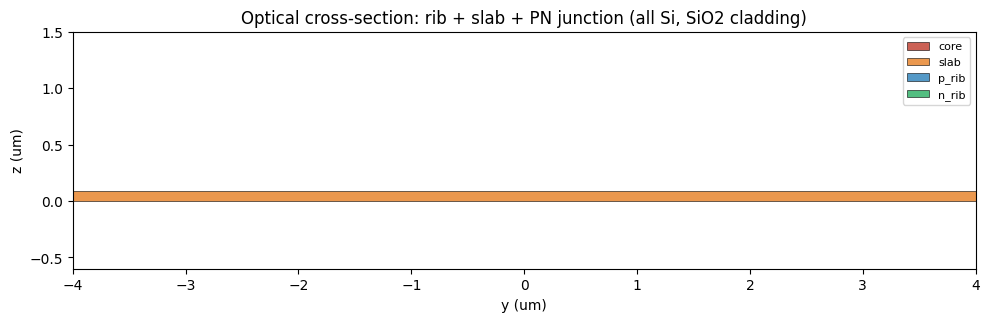

In [5]:
import matplotlib.pyplot as plt

from gsim.palace import plot_plane_section

PLOT_ZOOM_OPT = {"h_range": (-4.0, 4.0), "v_range": (-0.6, 1.5)}
PLOT_COLORS_OPT = {
    "core": "#c0392b",  # rib Si
    "slab": "#e67e22",  # slab Si
    "p_rib": "#2980b9",  # PN junction P region (Si)
    "n_rib": "#27ae60",  # PN junction N region (Si)
}
PLOT_TITLE_OPT = (
    "Optical cross-section: rib + slab + PN junction (all Si, SiO2 cladding)"
)

plot_plane_section(
    section_opt,
    colors=PLOT_COLORS_OPT,
    h_range=PLOT_ZOOM_OPT["h_range"],
    v_range=PLOT_ZOOM_OPT["v_range"],
    title=PLOT_TITLE_OPT,
)
plt.tight_layout()
plt.show()

### Optical material properties (1550 nm)

The PDK stack materials resolve to their Sellmeier optical constants at the
simulation wavelength. The Palace boundary-mode config generator evaluates
dispersion at `F_OPT` automatically; the values below are for reference.

In [6]:
import math

from gsim.common.stack.materials import resolve_material_at_wavelength

LAMBDA_OPT = 1.55  # reference wavelength (um)

si_opt = resolve_material_at_wavelength("si", LAMBDA_OPT)
sio2_opt = resolve_material_at_wavelength("sio2", LAMBDA_OPT)
print(
    f"si   @ {LAMBDA_OPT:.2f} um: eps={si_opt.permittivity_scalar:.4f}  n={math.sqrt(si_opt.permittivity_scalar):.4f}"
)
print(
    f"sio2 @ {LAMBDA_OPT:.2f} um: eps={sio2_opt.permittivity_scalar:.4f}  n={math.sqrt(sio2_opt.permittivity_scalar):.4f}"
)

si   @ 1.55 um: eps=12.0946  n=3.4777
sio2 @ 1.55 um: eps=2.0852  n=1.4440


## Plot the 2D cross-section

The physical-group regions are rendered with the reusable
`gsim.palace.plot_plane_section()`. The full layout spans ~140 um, so we zoom
on the central region to show the rib, PN junction, graded doping and vias.


In [7]:
# --- Cross-section plot parameters (physical-group regions) ---------------
PLOT_ZOOM = {"h_range": (-15.0, 15.0), "v_range": (-0.5, 5.0)}
PLOT_COLORS = {
    "core": "#c0392b",  # rib Si -- red
    "slab90": "#e67e22",  # slab Si -- orange
    "p_rib": "#2980b9",  # P doping -- blue
    "pp_slab_0": "#8e44ad",  # P+ graded inner -- purple
    "pp_slab_1": "#a569bd",  # P+ graded outer -- light purple
    "n_rib": "#27ae60",  # N doping -- green
    "npp_slab_0": "#4460ad",  # N+ graded inner -- indigo
    "npp_slab_1": "#5b7dcf",  # N+ graded outer -- light indigo
    "metal1": "#7f8c8d",  # CPW electrodes (Al) -- grey
    "metal2": "#7f8c8d",
    "metal3": "#7f8c8d",
    "via_contact": "#f1c40f",  # via -- gold
    "via1": "#f1c40f",
    "via2": "#f1c40f",
}
PLOT_TITLE = "TW-MZM cross-section (zoomed on rib + doping + signal electrode)"

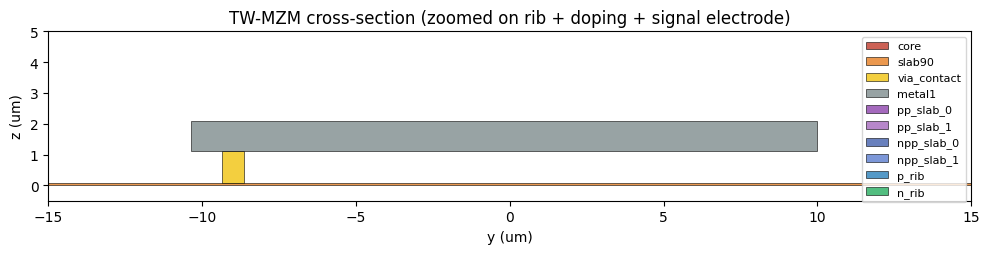

In [8]:
import matplotlib.pyplot as plt

from gsim.palace import plot_plane_section

plot_plane_section(
    section,
    colors=PLOT_COLORS,
    h_range=PLOT_ZOOM["h_range"],
    v_range=PLOT_ZOOM["v_range"],
    title=PLOT_TITLE,
)
plt.tight_layout()
plt.show()

## RF simulation (50 GHz)

Configure the 50 GHz BoundaryMode run: simulation airbox, mesh, number of
modes, output directory, and the field quantities to plot.


In [9]:
# =============================================================================
#  RF parameters (50 GHz BoundaryMode run)
# =============================================================================

# --- Simulation box (airbox + mesh margins, um) -----------------------------
AIRBOX = {"margin_x": 50.0, "margin_y": 50.0, "z_above": 100.0, "z_below": 100.0}
MESH_MARGIN_X = 0.0
MESH_MARGIN_Y = 50.0

# --- RF solver settings -----------------------------------------------------
F_RF = 50e9
NUM_RF_MODES = 2
RF_OUTPUT_DIR = "./palace-sim-mzm-pn"
RF_MESH = {
    "preset": "default",
    "refined_mesh_size": 0.05,
    "max_mesh_size": 40.0,
    "fmax": 150e9,
}

# --- RF post-processing -----------------------------------------------------
RF_FIELD = "E_real"
RF_FIELD_TITLE = "RF Mode |E| at x=0 (50 GHz)"
RIB_PHYSICAL_GROUPS = [
    "n_rib",
    "npp_slab_0",
    "npp_slab_1",
    "p_rib",
    "pp_slab_0",
    "pp_slab_1",
]

# --- PN junction lumped model -------------------------------------------------
PN_JUNCTION_CAPACITANCE = 1e-15  # F, on the p_rib / n_rib interface

In [10]:
from gsim.palace import BoundaryModeSim

# -- Boundary 2D simulation setup (RF) ----------------------------------
sim = BoundaryModeSim()
sim.set_output_dir(RF_OUTPUT_DIR)
sim.set_stack(stack)
sim.set_airbox(**AIRBOX)
sim.set_geometry(comp)

sim.set_cross_section(f"{CROSS_SECTION_AXIS}={CROSS_SECTION_VALUE}")
sim.set_boundary_mode(freq=F_RF, num_modes=NUM_RF_MODES, save=2)

# -- Mesh ---------------------------------------------------------------------
sim.mesh(
    preset=RF_MESH["preset"],
    refined_mesh_size=RF_MESH["refined_mesh_size"],
    max_mesh_size=RF_MESH["max_mesh_size"],
    fmax=RF_MESH["fmax"],
    margin_x=MESH_MARGIN_X,
    margin_y=MESH_MARGIN_Y,
)

# Show the 2D domain groups created by the solver
domain_groups = list(sim._last_mesh_result.groups["volumes"].keys())
print("2D domain groups:", domain_groups)
sim.print_mesh_stats()

INFO Generating mesh in palace-sim-mzm-pn


INFO Extracting geometry...
INFO   Polygons: 17
INFO   Bbox: (-5.0, -70.0, 10.0, 70.0)
INFO Building native 2D BoundaryMode geometry...
INFO Filtered 14 internal conductor curves for 'metal1' (2 remaining)
INFO Filtered 6 internal conductor curves for 'via_contact' (2 remaining)
INFO Generating native 2D BoundaryMode mesh...


2D domain groups: ['n_rib', 'npp_slab_0', 'npp_slab_1', 'p_rib', 'passive', 'pp_slab_0', 'pp_slab_1', 'sio2', 'slab90', 'air']
  Bounding box: 340.000 x 208.600 x 0.000 um
  Nodes:     42,253
  Elements:  103,726
  Domain groups:     10
  Conductor surfaces:2
  Interface surfaces:17
  Est. ND-space DOFs (order 2):  ~622,356
  Est. H1-space DOFs (order 2):  ~622,356
  Est. total DOFs:                  ~1,244,712


In [ ]:
# Interactive 3D mesh visualisation
sim.plot_mesh(
    transparent_groups=["air__None", "air__passive", "oxide__passive"],
    style="solid",
    interactive=True,
)

INFO Solid plot: using 1 surface cell blocks
INFO awaiting runner setup
INFO awaiting site startup
INFO Print WSLINK_READY_MSG
INFO Schedule auto shutdown with timeout 0
INFO awaiting running future


Widget(value='<iframe src="http://localhost:34191/index.html?ui=P_0x75d50ef6fb00_0&reconnect=auto" class="pyvi…

INFO 127.0.0.1 [10/Aug/2026:17:43:00 -0300] "GET /index.html?ui=P_0x75d402f5ee70_3&reconnect=auto HTTP/1.1" 200 237 "-" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Code/1.115.0 Chrome/142.0.7444.265 Electron/39.8.5 Safari/537.36"
INFO 127.0.0.1 [10/Aug/2026:17:43:00 -0300] "GET /assets/index-DBTNMoYm.js HTTP/1.1" 200 246 "http://localhost:34191/index.html?ui=P_0x75d402f5ee70_3&reconnect=auto" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Code/1.115.0 Chrome/142.0.7444.265 Electron/39.8.5 Safari/537.36"
INFO 127.0.0.1 [10/Aug/2026:17:43:00 -0300] "GET /vue.global.js HTTP/1.1" 200 247 "http://localhost:34191/index.html?ui=P_0x75d402f5ee70_3&reconnect=auto" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Code/1.115.0 Chrome/142.0.7444.265 Electron/39.8.5 Safari/537.36"
INFO 127.0.0.1 [10/Aug/2026:17:43:00 -0300] "GET /assets/index-faLoIDve.css HTTP/1.1" 200 235 "http://localhost:34191/index.html?ui=P_0x75d402f5e

In [12]:
# Generate Palace config file (mesh must be present)
sim.add_impedance_boundary("p_rib", "n_rib", capacitance=PN_JUNCTION_CAPACITANCE)
sim.write_config()
print("Config written to:", sim.output_dir)

Config written to: palace-sim-mzm-pn


In [13]:
# -- RF simulation (50 GHz) ------------------------------------------------
results = sim.run_local(verbose=True)
results.print()

INFO Parallel config: 1 MPI rank(s), 8 OpenMP thread(s)
INFO resolve_palace_binary: using palace-toolkit-cpu bundled binary /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace
INFO Palace binary: /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace  (source: palace-toolkit-cpu)
INFO >> /usr/bin/mpirun -n 1 /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace-x86_64.bin --version

Palace version: v0.17.0-194-g01f5d9bd1
Schema version: 1-3-1
INFO Running Palace simulation in palace-sim-mzm-pn directly
INFO Command: /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace -np 1 -nt 8 config.json
INFO Processes: 1
INFO >> /usr/bin/mpirun -n 1 /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace-x86_64.bin config.json
INFO _____________     _______
INFO _____   __   \____ __   

mode 1: k_n = +1.968127e+03-8.285353e+01j, n_eff = +1.878123e+00-7.906456e-02j, eta_eff ~= 200.23+8.43j
mode 2: k_n = +1.526458e+03-1.284639e+01j, n_eff = +1.456652e+00-1.225891e-02j, eta_eff ~= 258.61+2.18j


In [14]:
# --- Post-processing: RF mode fields ---
import importlib

import gsim.palace.field_viz as field_viz
import gsim.palace.results as palace_results
from gsim.palace import plot_fields_2d

importlib.reload(field_viz)
importlib.reload(palace_results)

if not hasattr(results, "modes"):
    results = palace_results.load_text_results(RF_OUTPUT_DIR)

results.print()

pl = plot_fields_2d(
    RF_OUTPUT_DIR,
    field=RF_FIELD,
    title=RF_FIELD_TITLE,
    interactive=True,
)

mode 1: k_n = +1.968127e+03-8.285353e+01j, n_eff = +1.878123e+00-7.906456e-02j, eta_eff ~= 200.23+8.43j
mode 2: k_n = +1.526458e+03-1.284639e+01j, n_eff = +1.456652e+00-1.225891e-02j, eta_eff ~= 258.61+2.18j


INFO Input field is already 2D in z-normal plane; ignoring normal=x


Widget(value='<iframe src="http://localhost:34191/index.html?ui=P_0x75d402f91370_1&reconnect=auto" class="pyvi…

In [15]:
# --- Rib waveguide zoom: select by physical group names ---
from gsim.palace import plot_fields_2d

pl = plot_fields_2d(
    RF_OUTPUT_DIR,
    field=RF_FIELD,
    physical_groups=RIB_PHYSICAL_GROUPS,
    title="RF Mode |E| in the Rib Waveguide (50 GHz, zoomed)",
    interactive=True,
)

INFO Selected 1172 / 67925 cells for physical_groups=['n_rib', 'npp_slab_0', 'npp_slab_1', 'p_rib', 'pp_slab_0', 'pp_slab_1']
INFO Input field is already 2D in z-normal plane; ignoring normal=x


Widget(value='<iframe src="http://localhost:34191/index.html?ui=P_0x75d50ea288c0_2&reconnect=auto" class="pyvi…

## Optical simulation (1550 nm)

The **simplified optical component** (rib + slab + PN junction, all Si) is
analysed at optical frequencies to compute the mode confined in the rib
waveguide. It uses the minimal all-dielectric stack with a **uniform SiO2
cladding** and **no air**: the padded 2D domain background is set to SiO2 via
`set_airbox(material="sio2", ...)` instead of the default air.
`run_local()` locates the Palace binary internally — there is no
manual `subprocess` / binary-search here.

Material dispersion is evaluated at `F_OPT` by the boundary-mode config
generator, so the Si and SiO2 domains use their Sellmeier optical constants.

In [16]:
# =============================================================================
#  Optical parameters (1550 nm BoundaryMode run)
# =============================================================================

F_OPT = 193.4e12  # ~1550 nm
LAMBDA_OPT = 1.55  # reference wavelength (um)
NUM_OPT_MODES = 4
TARGET_INDEX = 2.5
TOLERANCE = 1e-8
OPT_OUTPUT_DIR = "./palace-sim-mzm-pn-opt"
OPT_MESH = {
    "preset": "default",
    "refined_mesh_size": 0.2,
    "max_mesh_size": 0.5,
}

# Optical post-processing
OPT_FIELD = "E_real"
OPT_FIELD_TITLE = "Optical Mode |E| at x=0 (1550 nm)"
OPT_RIB_PHYSICAL_GROUPS = ["slab", "p_rib", "n_rib"]

In [17]:
# -- Optical setup + run (1550 nm) ---------------------------------------
sim_optical = BoundaryModeSim()
sim_optical.set_output_dir(OPT_OUTPUT_DIR)
sim_optical.set_stack(stack_opt)
# Uniform SiO2 cladding: the padded 2D domain is filled with SiO2 (material=
# "sio2") instead of air, so the device sits in a uniform dielectric background.
# Only modest padding is needed since the cladding now surrounds the rib
# directly. The "absorbing boundary on solid dielectric" warning from mesh() is
# expected here — for an eigenmode cross-section the PML sits far from the mode.
sim_optical.set_airbox(
    material="sio2",
    margin_x=3.0,
    margin_y=3.0,
    z_above=3.0,
    z_below=2.0,
)
sim_optical.set_geometry(comp_optical)

sim_optical.set_cross_section(f"{CROSS_SECTION_AXIS}={CROSS_SECTION_VALUE}")
sim_optical.set_boundary_mode(
    freq=F_OPT,
    num_modes=NUM_OPT_MODES,
    save=2,
    target=TARGET_INDEX,
    tolerance=TOLERANCE,
)

# Optical constants at 1550 nm (Sellmeier). The config generator also resolves
# dispersion at F_OPT automatically; these overrides keep the config explicit.
sim_optical.set_material(
    "si", material_type="dielectric", permittivity=si_opt.permittivity_scalar
)
sim_optical.set_material(
    "sio2", material_type="dielectric", permittivity=sio2_opt.permittivity_scalar
)

sim_optical.mesh(
    preset=OPT_MESH["preset"],
    refined_mesh_size=OPT_MESH["refined_mesh_size"],
    max_mesh_size=OPT_MESH["max_mesh_size"],
)

# The optical-only stack has no conductors (only shaped dielectrics), which the
# default write_config() mesh validation accepts. Generate config.json so the
# local run below has something to submit.
sim_optical.write_config()

INFO Generating mesh in palace-sim-mzm-pn-opt
INFO Extracting geometry...
INFO   Polygons: 4
INFO   Bbox: (-5.0, -50.2, 10.0, 50.2)
INFO Building native 2D BoundaryMode geometry...
INFO Generating native 2D BoundaryMode mesh...
WARNING Absorbing boundary is applied to solid dielectric surfaces (n_rib, p_rib, sio2, slab) because the model has no air region, which produces large spurious insertion loss and reflection. Add an airbox via set_airbox(margin_x=..., margin_y=..., z_above=..., z_below=...). Note that get_stack(air_above=...) is deprecated and ignored.


PosixPath('palace-sim-mzm-pn-opt/config.json')

In [18]:
# Interactive 3D mesh visualisation
sim_optical.plot_mesh(
    transparent_groups=["air__None", "air__passive", "oxide__passive"],
    style="solid",
    interactive=True,
)

INFO Solid plot: using 1 surface cell blocks


Widget(value='<iframe src="http://localhost:34191/index.html?ui=P_0x75d402f5ee70_3&reconnect=auto" class="pyvi…

In [19]:
opt_results = sim_optical.run_local(verbose=True)
opt_results.print()

INFO Parallel config: 1 MPI rank(s), 8 OpenMP thread(s)
INFO resolve_palace_binary: using palace-toolkit-cpu bundled binary /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace
INFO Palace binary: /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace  (source: palace-toolkit-cpu)
INFO >> /usr/bin/mpirun -n 1 /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace-x86_64.bin --version

Palace version: v0.17.0-194-g01f5d9bd1
Schema version: 1-3-1
INFO Running Palace simulation in palace-sim-mzm-pn-opt directly
INFO Command: /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace -np 1 -nt 8 config.json
INFO Processes: 1
INFO >> /usr/bin/mpirun -n 1 /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace-x86_64.bin config.json
INFO _____________     _______
INFO _____   __   \____ _

mode 1: k_n = +9.993833e+06+2.288009e-07j, n_eff = +2.465565e+00+5.644716e-14j, eta_eff ~= 152.80-0.00j
mode 2: k_n = +8.525452e+06+3.799696e-04j, n_eff = +2.103303e+00+9.374179e-11j, eta_eff ~= 179.11-0.00j
mode 3: k_n = +8.525423e+06+3.076833e-05j, n_eff = +2.103296e+00+7.590814e-12j, eta_eff ~= 179.11-0.00j
mode 4: k_n = +8.525114e+06-1.290861e-05j, n_eff = +2.103219e+00-3.184666e-12j, eta_eff ~= 179.12+0.00j


In [ ]:
# --- Optical mode in the rib waveguide (1550 nm) ---
from gsim.palace import plot_fields_2d

pl = plot_fields_2d(
    OPT_OUTPUT_DIR,
    field=OPT_FIELD,
    title=OPT_FIELD_TITLE,
    interactive=True,
)

In [ ]:
# --- Rib waveguide zoom: optical physical groups (all Si) ---
pl = plot_fields_2d(
    OPT_OUTPUT_DIR,
    field=OPT_FIELD,
    physical_groups=OPT_RIB_PHYSICAL_GROUPS,
    title="Optical Mode |E| in the Rib Waveguide (1550 nm, zoomed)",
    interactive=True,
)

## Summary

The geometry has been built and meshed for both RF (50 GHz) and optical (193 THz / 1550 nm) analysis.

**Cross-section elements:**
| Component | Layer | y-range (um) | z-range (um) | Material | sigma (S/m) |
|---|---|---|---|---|---|
| Rib core | WG (1,0) | [-20.2, -19.8] | [0, 0.22] | Si (intrinsic) | 2 |
| Slab (90 nm) | SLAB90 (3,0) | [-40.2, +0.2] | [0, 0.09] | Si (intrinsic) | 2 |
| PN junction (P) | P (21,0) | [-20.0, -19.8] | [0, 0.22] | doped Si (p_rib) | 1.6x10^3 |
| PN junction (N) | N (20,0) | [-20.2, -20.0] | [0, 0.22] | doped Si (n_rib) | 1.6x10^3 |
| P+ graded inner | PP (23,0) | [-18.3, -16.3] | [0, 0.09] | doped Si (pp_slab_0) | 2x10^4 |
| P+ graded outer | PP (23,1) | [-15.3, -13.3] | [0, 0.09] | doped Si (pp_slab_1) | 8x10^4 |
| N+ graded inner | NPP (24,0) | [-21.7, -23.7] | [0, 0.09] | doped Si (npp_slab_0) | 2x10^4 |
| N+ graded outer | NPP (24,1) | [-24.7, -26.7] | [0, 0.09] | doped Si (npp_slab_1) | 8x10^4 |
| Vias (S to P+) | VIAC/VIA1/VIA2 | [-15.0, -9.0] | [0.09, 3.2] | W/Al | 3.5x10^7 |
| Vias (G to N+) | VIAC/VIA1/VIA2 | [-31.0, -25.0] | [0.09, 3.2] | W/Al | 3.5x10^7 |
| CPW signal | M1 (41,0) | [-10, +10] | [3.2, 4.2] | Al (1 um) | 3.5x10^7 |
| CPW ground (top) | M1 (41,0) | [+30, +70] | [3.2, 4.2] | Al (1 um) | 3.5x10^7 |
| CPW ground (bot) | M1 (41,0) | [-70, -30] | [3.2, 4.2] | Al (1 um) | 3.5x10^7 |

**Material modelling notes:**
- Doping regions are modelled as **semiconductors** (finite sigma from the Drude free-carrier model), not metals. This avoids short-circuiting the PN junction.
- Conductivities are derived from $\sigma = q\mu N$ with typical dopant concentrations ($N \sim 10^{19}\ \text{cm}^{-3}$ for the junction, $\sim 10^{20}\ \text{cm}^{-3}$ for the contacts).
- Doping on each side of the rib uses a **configurable piecewise gradient** via `make_doping_profile()`, and the whole cross-section assembly is wrapped by `build_doped_cross_section()`.
- The **depletion region** and voltage-dependent capacitance are NOT modelled here — this is a linear small-signal analysis at a fixed bias point.
- The **plasma-dispersion effect** is not applied to the optical simulation; the rib is treated as intrinsic Si at 1550 nm.

**Optical-only component:**
- The optical run (`sim_optical`) uses a **simplified component** — the same
  rib + slab + PN junction ("doping profile") polygons, but no electrodes,
  vias, or graded doping.
- Every device region maps to **plain silicon** in `build_optical_cross_section()`,
  so the optical mode sees one homogeneous Si body in a **uniform SiO2 cladding**.
- The background medium is SiO2, not air: `set_airbox(material="sio2", ...)`
  fills the padded 2D domain with the cladding material (default is air).
- Material dispersion is evaluated at `F_OPT` by the boundary-mode config
  generator: Si -> eps~12.09 (n~3.478), SiO2 -> eps~2.09 (n~1.444) at 1550 nm.

**Next steps (user action):**
1. Verify the zoomed cross-section plot shows the rib (centred at y=-20), PN junction, graded doping, and vias.
2. Run `sim.run_local(verbose=True)` with a Palace CPU runner installed (`pip install gsim[palace-toolkit-cpu]`). 2D
   mode analysis defaults to a single MPI rank + OpenMP threads; pass `num_processes=1` explicitly if you want
   to be explicit about it.
3. Run `sim_optical.run_local(verbose=True)` for the optical mode.
4. Use `gsim.palace.plot_fields_2d()` to visualise mode profiles, and `gsim.palace.plot_plane_section()` for cross-section physical groups.


In [20]:
# Quick verification: dump the 2D cross-section layer regions
print("=== RF cross-section regions (x=0) ===")
for r in section:
    print(
        f"  {r.layer_name:12s}  mat={r.material:10s}  "
        f"y=[{r.y0:6.2f},{r.y1:6.2f}]  z=[{r.zmin:5.3f},{r.zmax:5.3f}]"
    )
print("\n=== Optical cross-section regions (x=0) ===")
for r in section_opt:
    print(
        f"  {r.layer_name:12s}  mat={r.material:10s}  "
        f"y=[{r.y0:6.2f},{r.y1:6.2f}]  z=[{r.zmin:5.3f},{r.zmax:5.3f}]"
    )

=== RF cross-section regions (x=0) ===
  core          mat=si          y=[-20.20,-19.80]  z=[0.000,0.220]
  slab90        mat=si          y=[-50.20, 50.20]  z=[0.000,0.090]
  via_contact   mat=Aluminum    y=[-29.35,-28.65]  z=[0.090,1.100]
  via_contact   mat=Aluminum    y=[ -9.35, -8.65]  z=[0.090,1.100]
  metal1        mat=Aluminum    y=[-70.00,-27.65]  z=[1.100,2.100]
  metal1        mat=Aluminum    y=[-10.35, 10.00]  z=[1.100,2.100]
  metal1        mat=Aluminum    y=[ 30.00, 70.00]  z=[1.100,2.100]
  pp_slab_0     mat=pp_slab_0   y=[-19.80,-17.80]  z=[0.000,0.090]
  pp_slab_1     mat=pp_slab_1   y=[-17.80,-15.80]  z=[0.000,0.090]
  npp_slab_0    mat=npp_slab_0  y=[-22.20,-20.20]  z=[0.000,0.090]
  npp_slab_1    mat=npp_slab_1  y=[-24.20,-22.20]  z=[0.000,0.090]
  p_rib         mat=p_rib       y=[-20.00,-19.80]  z=[0.000,0.220]
  n_rib         mat=n_rib       y=[-20.20,-20.00]  z=[0.000,0.220]

=== Optical cross-section regions (x=0) ===
  core          mat=si          y=[-20.20,-19